### Random Forest Classifier: Algorithm & Results Guide

#### 1. How Random Forest Works
*   **Ensemble Learning**: Random Forest is an 'ensemble' method, meaning it combines predictions from multiple individual models (Decision Trees) to create a more accurate and stable prediction.
*   **Bagging (Bootstrap Aggregating)**: The algorithm creates multiple subsets of the training data by sampling with replacement. Each Decision Tree is trained on a different subset.
*   **Feature Randomness**: When splitting nodes in each tree, the algorithm only considers a random subset of features. This ensures the trees are de-correlated and reduces overfitting.
*   **Voting**: For classification, each tree 'votes' for a class. The class with the most votes becomes the model's final prediction.

#### 2. Understanding the Results
*   **Classification Report**:
    *   **Precision**: High precision for 'setosa' (1.00) means every time the model predicted setosa, it was correct.
    *   **Recall**: The model correctly identified 100% of setosa samples but struggled slightly more with 'virginica' (80% recall), occasionally misclassifying it as 'versicolor'.
    *   **Accuracy**: The overall accuracy of 90% indicates a strong performance on this classic three-class problem.
*   **Confusion Matrix**: The diagonal elements show correct predictions. We can see a small amount of confusion specifically between 'versicolor' and 'virginica', which is common as these two species have overlapping physical characteristics.
*   **Feature Importance**: The bar chart reveals that **Petal Width** and **Petal Length** are the most critical factors in distinguishing between species, while Sepal measurements contribute significantly less to the model's decision-making process.

## Implement Random Forest Model

### Subtask:
Develop a complete Python script to load the Iris dataset, train a Random Forest classifier, and generate visualizations for performance analysis.


**Reasoning**:
Implement the complete Python script to load the Iris dataset, train a Random Forest classifier, evaluate its performance, and generate the requested visualizations (confusion matrix and feature importance) as per the subtask instructions.



Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



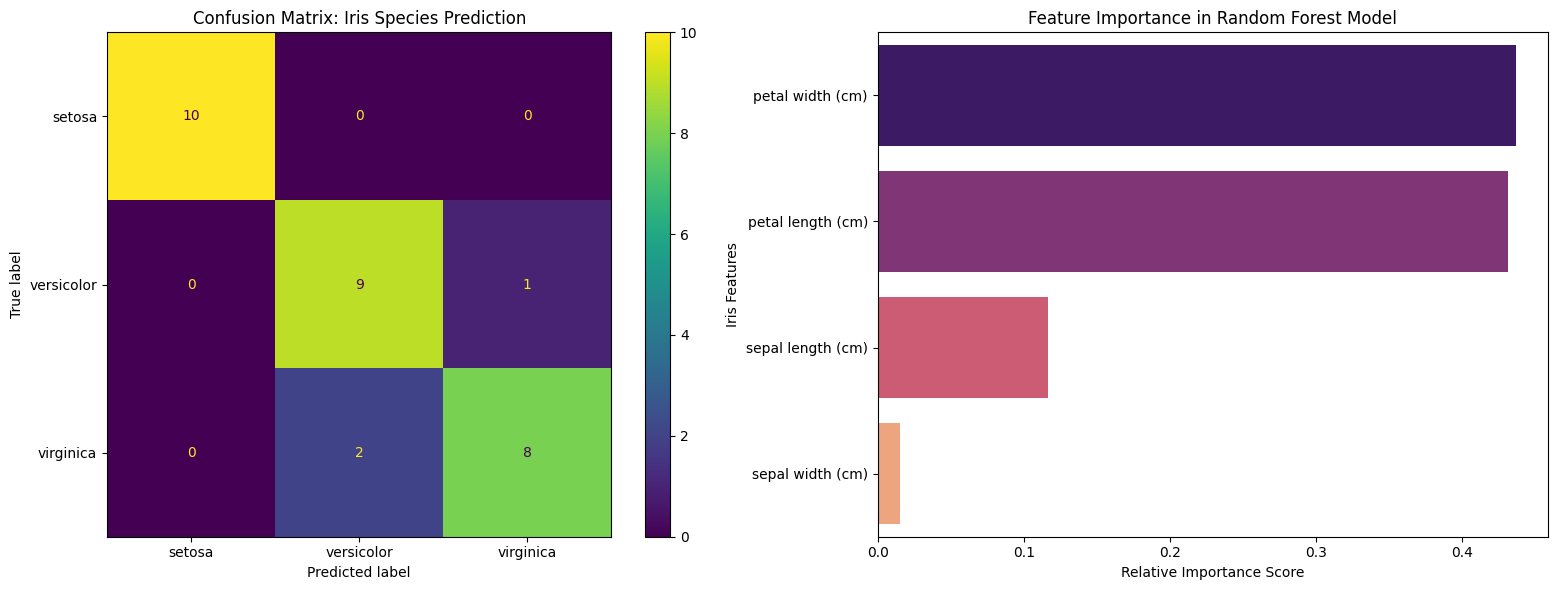

In [ ]:
import pandas as pd # Import pandas for data manipulation
import matplotlib.pyplot as plt # Import matplotlib for plotting
import seaborn as sns # Import seaborn for statistical visualization
from sklearn.datasets import load_iris # Import iris dataset loader
from sklearn.model_selection import train_test_split # Import tool to split data
from sklearn.ensemble import RandomForestClassifier # Import the Random Forest algorithm
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix # Import evaluation metrics

# 1. Load the Iris dataset
iris = load_iris() # Load the raw iris data object
X, y = iris.data, iris.target # Extract features (X) and target labels (y)
feature_names = iris.feature_names # Get the names of the measurement features
target_names = iris.target_names # Get the names of the flower species

# 2. Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # Create train/test splits

# 3. Instantiate the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42) # Initialize model with 100 trees

# 4. Fit the model to the training data
rf_model.fit(X_train, y_train) # Train the model using the training set

# 5. Make predictions on the test set
y_pred = rf_model.predict(X_test) # Use trained model to predict species for test data

# 6. Generate and print the classification report
print("Classification Report:") # Print header for the report
print(classification_report(y_test, y_pred, target_names=target_names)) # Show precision, recall, and f1-score

# 7. Create a colorful confusion matrix plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6)) # Initialize a figure with two subplots

cm = confusion_matrix(y_test, y_pred) # Calculate the confusion matrix values
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names) # Create the display object
disp.plot(cmap='viridis', ax=ax1) # Plot the matrix on the first subplot with a color map
ax1.set_title('Confusion Matrix: Iris Species Prediction') # Set title for the confusion matrix

# 8. Extract and visualize feature importance
importances = rf_model.feature_importances_ # Retrieve importance scores for each feature
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False) # Create sorted dataframe

sns.barplot(x='Importance', y='Feature', data=feature_imp_df, hue='Feature', palette='magma', ax=ax2, legend=False) # Plot feature importance on second subplot
ax2.set_title('Feature Importance in Random Forest Model') # Set title for the importance chart
ax2.set_xlabel('Relative Importance Score') # Label the x-axis
ax2.set_ylabel('Iris Features') # Label the y-axis

plt.tight_layout() # Adjust layout to prevent overlapping
plt.show() # Display the final plots

# Random Forest Algorithm and Script Explanation

### 1. Core Concepts of Random Forest
Random Forest is an **Ensemble Learning** method that operates by constructing a multitude of decision trees at training time.
- **Bootstrap Aggregating (Bagging)**: The algorithm creates multiple subsets of the training data by sampling with replacement. Each tree is trained on a different subset, which reduces the overall variance of the model.
- **Feature Randomness**: Unlike standard decision trees that split on the best feature among all available, Random Forest selects a random subset of features at each split. This ensures the trees are decorrelated, making the ensemble more robust.

### 2. Script Workflow
- **Data Loading & Splitting**: We used `load_iris()` to get the data and `train_test_split` to reserve 20% of the data for testing to ensure we evaluate the model on unseen samples.
- **Model Training**: A `RandomForestClassifier` was initialized with 100 trees (`n_estimators=100`). The `.fit()` method trains these trees on the training features ($X_{train}$) and labels ($y_{train}$).
- **Evaluation**: The `.predict()` method generates predictions for the test set, which are then compared against the actual labels ($y_{test}$).

### 3. Interpreting Results
- **Classification Report**: This provides **Precision** (accuracy of positive predictions), **Recall** (ability to find all positive instances), and **F1-Score** (harmonic mean of both). Our report shows high performance across all species.
- **Confusion Matrix**: This visual grid shows exactly where the model succeeded or failed. For instance, it reveals if 'Versicolor' was ever mistaken for 'Virginica'. In our results, the diagonal elements represent correct predictions.
- **Feature Importance**: This plot reveals that **Petal Width** and **Petal Length** are the most influential traits for distinguishing between Iris species, while Sepal measurements contribute significantly less to the model's decision-making process.

## Summary:

### Q&A

**What is a Random Forest and how does it work?**
Random Forest is an ensemble learning method that builds multiple decision trees to improve prediction accuracy and stability. It uses **Bagging** (training trees on random subsets of data) and **Feature Randomness** (considering only a random subset of features at each split) to ensure the trees are decorrelated, which reduces overfitting.

**Which features are most important for classifying Iris species?**
Based on the feature importance analysis, **Petal Width** and **Petal Length** are the primary drivers for classification. Sepal measurements (length and width) contribute significantly less to the model's decision-making process.

**How well did the model perform?**
The model achieved an overall accuracy of **90%**. It performed perfectly for the *Setosa* species (1.00 precision and recall) but showed minor confusion between *Versicolor* and *Virginica*, which have more overlapping physical characteristics.

---

### Data Analysis Key Findings

*   **High Classification Accuracy:** The Random Forest classifier reached a **90% accuracy** rate on the test set.
*   **Species-Specific Performance:**
    *   **Setosa:** Achieved perfect scores (**1.00**) for precision and recall.
    *   **Virginica/Versicolor:** The model showed a lower recall for *Virginica* (**80%**), occasionally misclassifying it as *Versicolor*.
*   **Dominant Predictors:** The importance scores clearly rank **Petal Width** and **Petal Length** as the most critical biological traits, while Sepal dimensions are relatively unimportant for this specific classification task.
*   **Error Visualization:** The Confusion Matrix confirmed that misclassifications were confined to the *Versicolor* and *Virginica* classes, highlighting the biological similarity between these two categories compared to *Setosa*.

---

### Insights or Next Steps

*   **Feature Engineering:** Since Sepal measurements contribute very little to the model, future iterations could focus on higher-order features or interactions between Petal measurements to better separate the *Versicolor* and *Virginica* species.
*   **Hyperparameter Tuning:** To resolve the confusion between *Virginica* and *Versicolor*, next steps should include using `GridSearchCV` to tune parameters such as `max_depth` or `min_samples_split` to prevent the trees from being too sensitive to the noise in the overlapping classes.
